**Adding, removing, and sorting elements**

# STEP 1: Import Required Libraries
All libraries imported successfully!
NumPy version: 2.0.2
Pandas version: 2.2.2
# STEP 2: Load Dataset
Dataset Shape: (2500, 9)

First 50 rows:
   Moisture_Content  pH_Level  Fat_Content  Protein_Content  \
0         18.112583  6.896316    11.691804        12.686050   
1         33.669286  6.675847    13.048406        17.326298   
2         27.763836  6.007351    19.527306         6.001423   
3         24.163779  7.346165    10.780075         6.076527   
4         12.212503  4.701661    19.784045        12.909094   

   Contamination_Index  Color_Score  Texture_Score  Shelf_Life_Days  \
0             0.935663    86.470034      64.976917        17.914029   
1             0.809667    31.157761      82.272274        19.989531   
2             0.387543    43.076553      69.386675        60.085752   
3             1.869249    75.843371      35.831181         7.757850   
4             1.294911    56.303154      42.990617        40.792771   

  Quality_Grad

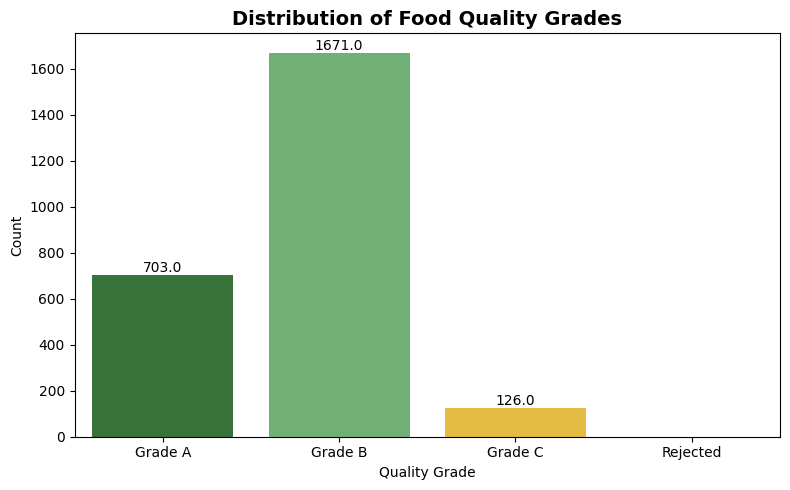

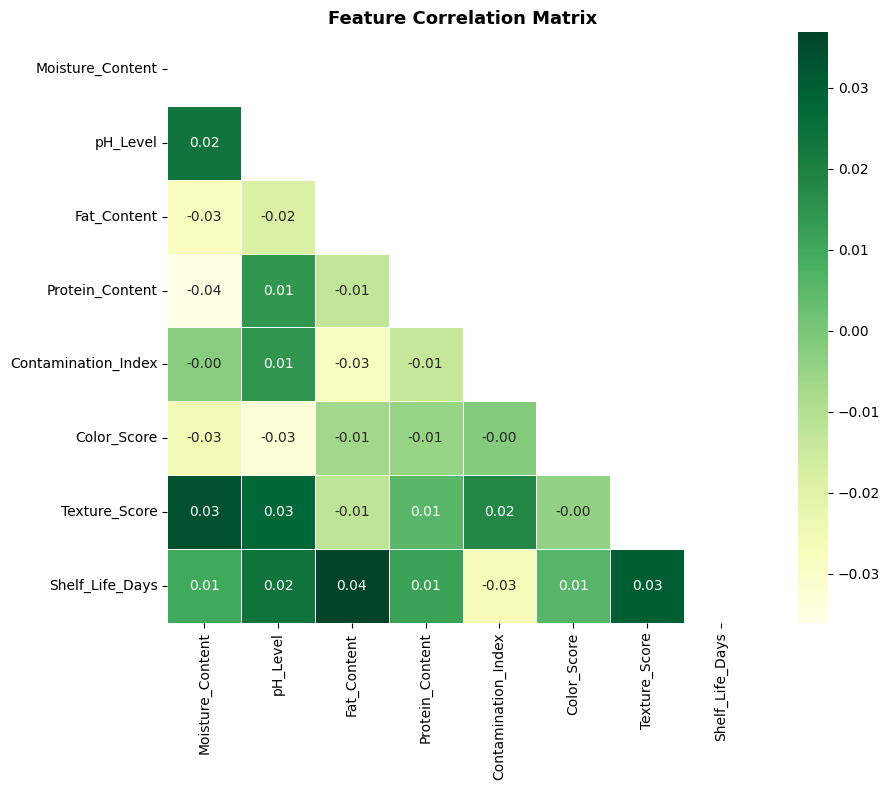

#STEP 4: Data Preprocessing
Class Mapping: {'Grade A': np.int64(0), 'Grade B': np.int64(1), 'Grade C': np.int64(2)}

Training Set: (2000, 8) | Test Set: (500, 8)
Scaling complete. Mean of training data: -0.0
# STEP 5: Model Training
Random Forest trained successfully!
Decision Tree trained successfully!
SVM trained successfully!
# STEP 6: Model Evaluation & Comparison

Model: Random Forest
Accuracy
: 0.9020 (90.20%)
F1-Score
: 0.8972

Detailed Report:
              precision    recall  f1-score   support

     Grade A       0.96      0.78      0.86       141
     Grade B       0.88      0.98      0.93       334
     Grade C       0.93      0.52      0.67        25

    accuracy                           0.90       500
   macro avg       0.92      0.76      0.82       500
weighted avg       0.91      0.90      0.90       500


Model: Decision Tree
Accuracy
: 0.8220 (82.20%)
F1-Score
: 0.8182

Detailed Report:
              precision    recall  f1-score   support

     Grade A       0.80

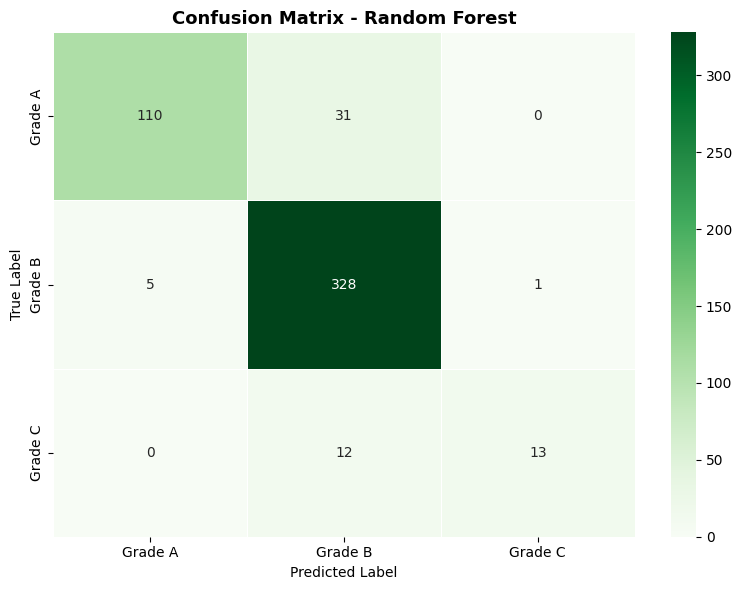

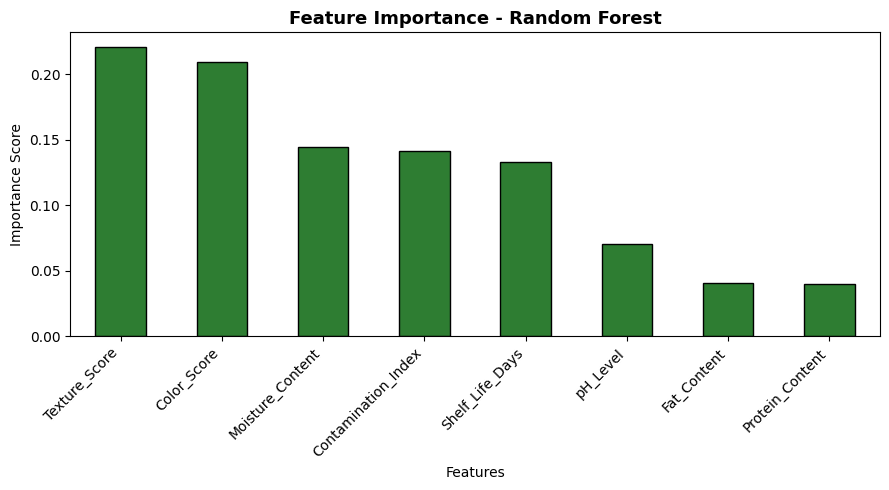


Top 3 Most Important Features:
Texture_Score       0.220984
Color_Score         0.209520
Moisture_Content    0.144146
dtype: float64
# STEP 7: Predict Quality Grade for a New Food Sample
FOOD QUALITY GRADING RESULT
Moisture Content : 13.0%
pH Level
: 6.9
Fat Content
: 8.0%
Protein Content
: 15.0%
Contamination Idx: 0.4
Color Score
: 88
Texture Score
: 90
Shelf Life
: 50 days
--------------------------------------------------
Predicted Quality Grade: Grade A


In [ ]:
# AI-Based Food Quality Grading of Processed Food
# BSc (Hons) Agriculture | UAS-REVA Collaboration
# Student: Ashwini Anant Bhat(AMB2025),Ashwini M(AMB2026), Bhumika S R(AMB2040)
# ============================================================
print("# STEP 1: Import Required Libraries")
# ============================================================
import numpy as np
# Numerical computations
import pandas as pd
# Data manipulation and analysis
import matplotlib.pyplot as plt
# Plotting and visualization
import seaborn as sns
# Statistical data visualization
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
accuracy_score, classification_report,
confusion_matrix, f1_score)
print("All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


# ============================================================
print("# STEP 2: Load Dataset")
# ============================================================
# For Google Colab, upload your CSV or use the synthetic generator below
# --- Option A: Load from CSV (after upload) ---
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('food_quality_dataset.csv')
# --- Option B: Generate Synthetic Dataset (for practice) ---
np.random.seed(42)
n = 2500
# Number of samples
df = pd.DataFrame({
'Moisture_Content': np.random.uniform(8, 35, n),
'pH_Level': np.random.uniform(4.0, 7.5, n),
'Fat_Content': np.random.uniform(5, 22, n),
'Protein_Content': np.random.uniform(4, 20, n),
'Contamination_Index': np.random.exponential(2, n).clip(0, 10),
'Color_Score': np.random.uniform(30, 100, n),
'Texture_Score': np.random.uniform(30, 100, n),
'Shelf_Life_Days': np.random.uniform(3, 65, n),
})
# Assign quality grades based on domain rules
def assign_grade(row):
    score = (
        (100 - row['Moisture_Content'] * 2) +
        (row['pH_Level'] * 10) +
        (row['Color_Score']) +
        (row['Texture_Score']) +
        (100 - row['Contamination_Index'] * 8) +
        (row['Shelf_Life_Days'] * 0.8)
    )
    if score >= 380: return 'Grade A'
    elif score >= 290: return 'Grade B'
    elif score >= 200: return 'Grade C'
    else:
        return 'Rejected'
df['Quality_Grade'] = df.apply(assign_grade, axis=1)
print(f"Dataset Shape: {df.shape}")
print("\nFirst 50 rows:")
print(df.head())
print("\nQuality Grade Distribution:")
print(df['Quality_Grade'].value_counts())


# ============================================================
print("# STEP 3: Exploratory Data Analysis")
# ============================================================
# 3.1 Basic Statistics
print("Basic Statistical Summary:")
print(df.describe())
# 3.2 Check for missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())
# 3.3 Class distribution visualization
plt.figure(figsize=(8, 5))
order = ['Grade A', 'Grade B', 'Grade C', 'Rejected']
colors = ['#2E7D32', '#66BB6A', '#FFCA28', '#EF5350']
ax = sns.countplot(x='Quality_Grade', data=df, order=order, palette=colors)
plt.title('Distribution of Food Quality Grades', fontsize=14, fontweight='bold')
plt.xlabel('Quality Grade')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('grade_distribution.png', dpi=150)
plt.show()
# 3.4 Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()


# ============================================================
print("#STEP 4: Data Preprocessing")
# ============================================================
# 4.1 Encode target variable
le = LabelEncoder()
df['Grade_Encoded'] = le.fit_transform(df['Quality_Grade'])
print("Class Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
# 4.2 Separate features and target

X = df.drop(columns=['Quality_Grade', 'Grade_Encoded'])
y = df['Grade_Encoded']
# 4.3 Train-Test Split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining Set: {X_train.shape} | Test Set: {X_test.shape}")
# 4.4 Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Fit on train only
X_test_scaled = scaler.transform(X_test)
# Transform test
print("Scaling complete. Mean of training data:",
X_train_scaled.mean().round(4))


# ============================================================
print("# STEP 5: Model Training")
# ============================================================
# -- 5.1 Random Forest Classifier --
rf_model = RandomForestClassifier(
n_estimators=100,
# 100 decision trees in the forest
max_depth=10,
# Limit tree depth to prevent overfitting
random_state=42,
class_weight='balanced' # Handle class imbalance
)
rf_model.fit(X_train_scaled, y_train)
print("Random Forest trained successfully!")
# -- 5.2 Decision Tree Classifier --
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)
dt_model.fit(X_train_scaled, y_train)
print("Decision Tree trained successfully!")
# -- 5.3 Support Vector Machine --
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)
print("SVM trained successfully!")


# ============================================================
print("# STEP 6: Model Evaluation & Comparison")
# ============================================================
models = {
'Random Forest': rf_model,
'Decision Tree': dt_model,
'SVM': svm_model


}
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'Accuracy': acc, 'F1-Score': f1}
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"Accuracy\n: {acc:.4f} ({acc*100:.2f}%)")
    print(f"F1-Score\n: {f1:.4f}")
    print("\nDetailed Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
# Best model
rf_pred = rf_model.predict(X_test_scaled)
# ---- Confusion Matrix (Random Forest) ----
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
xticklabels=le.classes_, yticklabels=le.classes_,
linewidths=0.5)
plt.title('Confusion Matrix - Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
# ---- Feature Importance ----
feat_imp = pd.Series(rf_model.feature_importances_,
index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 5))
feat_imp.plot(kind='bar', color='#2E7D32', edgecolor='black')
plt.title('Feature Importance - Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("\nTop 3 Most Important Features:")
print(feat_imp.head(3))


print("# STEP 7: Predict Quality Grade for a New Food Sample")
# ============================================================
# New sample: Moisture=13%, pH=6.9, Fat=8%, Protein=15%,
# # Contamination=0.4, Color=88, Texture=90, ShelfLife=50 days
new_sample = np.array([[13.0, 6.9, 8.0, 15.0, 0.4, 88.0, 90.0, 50.0]])
# Scale the new sample using the fitted scaler
new_sample_scaled = scaler.transform(new_sample)
# Predict
prediction = rf_model.predict(new_sample_scaled)
predicted_grade = le.inverse_transform(prediction)[0]
print("=" * 50)
print("FOOD QUALITY GRADING RESULT")
print("=" * 50)
print(f"Moisture Content : 13.0%")
print(f"pH Level\n: 6.9")
print(f"Fat Content\n: 8.0%")
print(f"Protein Content\n: 15.0%")
print(f"Contamination Idx: 0.4")
print(f"Color Score\n: 88")
print(f"Texture Score\n: 90")
print(f"Shelf Life\n: 50 days")
print("-" * 50)
print(f"Predicted Quality Grade: {predicted_grade}")
print("=" * 50)